# Cell 1 — Imports:

In [12]:
# Cell 1 - Imports & Config
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    classification_report
)

from src.config import (
    RAW_DATA_PATH,
    CONFUSION_MATRIX_PATH,
    ROC_CURVE_PATH
)
from src.preprocessor import (
    fix_total_charges,
    encode_target,
    get_feature_lists
)
from src.pipeline import build_lr_pipeline
from src.train import (
    train_with_gridsearch,
    get_lr_param_grid,
    evaluate_model
)

sns.set_theme(style="whitegrid")
print("✅ All imports successful")

✅ All imports successful


In [13]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

from src.config import (
    RAW_DATA_PATH,
    CONFUSION_MATRIX_PATH,
    ROC_CURVE_PATH,
    PIPELINE_PATH
)

print("RAW_DATA_PATH      :", RAW_DATA_PATH)
print("CONFUSION_MATRIX   :", CONFUSION_MATRIX_PATH)
print("ROC_CURVE_PATH     :", ROC_CURVE_PATH)
print("PIPELINE_PATH      :", PIPELINE_PATH)
print("\n✅ All paths imported successfully")

RAW_DATA_PATH      : C:\Users\aadil\OneDrive\Desktop\Study\Intership DEV_HUB\Phase 2\Advance_Tasks\Task 2 customer-churn-pipeline\Data\WA_Fn-UseC_-Telco-Customer-Churn.csv
CONFUSION_MATRIX   : C:\Users\aadil\OneDrive\Desktop\Study\Intership DEV_HUB\Phase 2\Advance_Tasks\Task 2 customer-churn-pipeline\models\plots\confusion_matrix.png
ROC_CURVE_PATH     : C:\Users\aadil\OneDrive\Desktop\Study\Intership DEV_HUB\Phase 2\Advance_Tasks\Task 2 customer-churn-pipeline\models\plots\roc_curve.png
PIPELINE_PATH      : C:\Users\aadil\OneDrive\Desktop\Study\Intership DEV_HUB\Phase 2\Advance_Tasks\Task 2 customer-churn-pipeline\models\churn_pipeline.pkl

✅ All paths imported successfully


# Cell 2  Reload & Prepare Data

In [14]:
# Cell 2 - Reload data and prepare
df = pd.read_csv(RAW_DATA_PATH)
df = fix_total_charges(df)
df = encode_target(df)

from sklearn.model_selection import train_test_split
from src.preprocessor import get_feature_lists

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Retrain best model (Logistic Regression)
lr_pipeline = build_lr_pipeline(df)
lr_grid = train_with_gridsearch(
    pipeline=lr_pipeline,
    param_grid=get_lr_param_grid(),
    X_train=X_train,
    y_train=y_train,
    model_name="Logistic Regression"
)

best_model = lr_grid.best_estimator_
print("Best model ready ✅")


Training Logistic Regression with GridSearchCV...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Best Parameters for Logistic Regression:
{'classifier__C': 1, 'classifier__max_iter': 1000, 'classifier__solver': 'liblinear'}

✅ Best CV F1 Score: 0.5971
Best model ready ✅


In [15]:
# Cell 2 - Load and prepare data
df = pd.read_csv(RAW_DATA_PATH)
df = fix_total_charges(df)
df = encode_target(df)

# Prepare features and target
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

# Stratified split - maintains class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ Data loaded and split")
print(f"   Train: {X_train.shape}")
print(f"   Test:  {X_test.shape}")

✅ Data loaded and split
   Train: (5634, 19)
   Test:  (1409, 19)


# Cell 3 — Train Best Model

In [16]:
# Cell 3 - Retrain best model (Logistic Regression)
lr_pipeline = build_lr_pipeline(df)

lr_grid = train_with_gridsearch(
    pipeline=lr_pipeline,
    param_grid=get_lr_param_grid(),
    X_train=X_train,
    y_train=y_train,
    model_name="Logistic Regression"
)

best_model = lr_grid.best_estimator_

print(f"\n✅ Best model ready")
print(f"   Best params: {lr_grid.best_params_}")
print(f"   CV F1 Score: {lr_grid.best_score_:.4f}")


Training Logistic Regression with GridSearchCV...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Best Parameters for Logistic Regression:
{'classifier__C': 1, 'classifier__max_iter': 1000, 'classifier__solver': 'liblinear'}

✅ Best CV F1 Score: 0.5971

✅ Best model ready
   Best params: {'classifier__C': 1, 'classifier__max_iter': 1000, 'classifier__solver': 'liblinear'}
   CV F1 Score: 0.5971


# Cell 4 — Classification Report


In [17]:
# Cell 4 - Full classification report
evaluate_model(
    lr_grid,
    X_test,
    y_test,
    "Logistic Regression"
)


Evaluation Report — Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
     Churned       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



# Cell 5 — Confusion Matrix


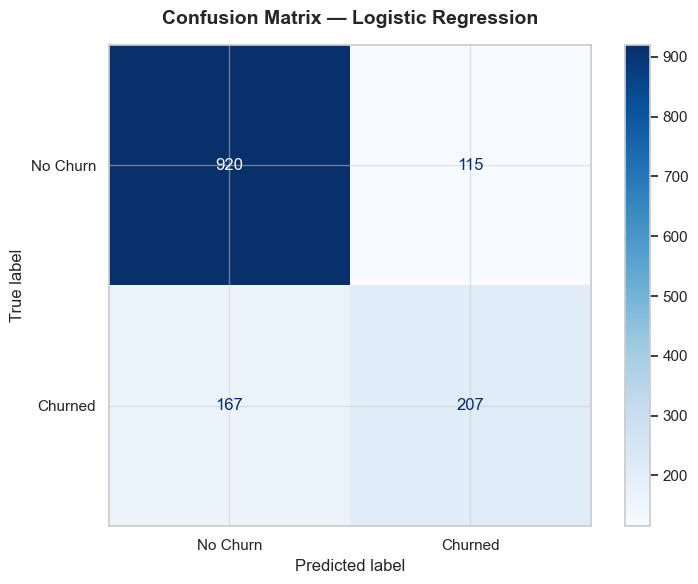


  CONFUSION MATRIX BREAKDOWN
  True Negatives  (correct No Churn) : 920
  False Positives (wrong churn alarm) : 115
  False Negatives (missed churners)   : 167 ⚠️
  True Positives  (caught churners)   : 207
  Churn Catch Rate : 55.3%
  Churners Missed  : 44.7%


In [18]:
# Cell 5 - Confusion Matrix
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churned']
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title(
    'Confusion Matrix — Logistic Regression',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH,
            dpi=150, bbox_inches='tight')
plt.show()

# Business interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\n{'='*45}")
print(f"  CONFUSION MATRIX BREAKDOWN")
print(f"{'='*45}")
print(f"  True Negatives  (correct No Churn) : {tn}")
print(f"  False Positives (wrong churn alarm) : {fp}")
print(f"  False Negatives (missed churners)   : {fn} ⚠️")
print(f"  True Positives  (caught churners)   : {tp}")
print(f"{'='*45}")
print(f"  Churn Catch Rate : {tp/(tp+fn)*100:.1f}%")
print(f"  Churners Missed  : {fn/(tp+fn)*100:.1f}%")
print(f"{'='*45}")

# Cell 6 — ROC Curve


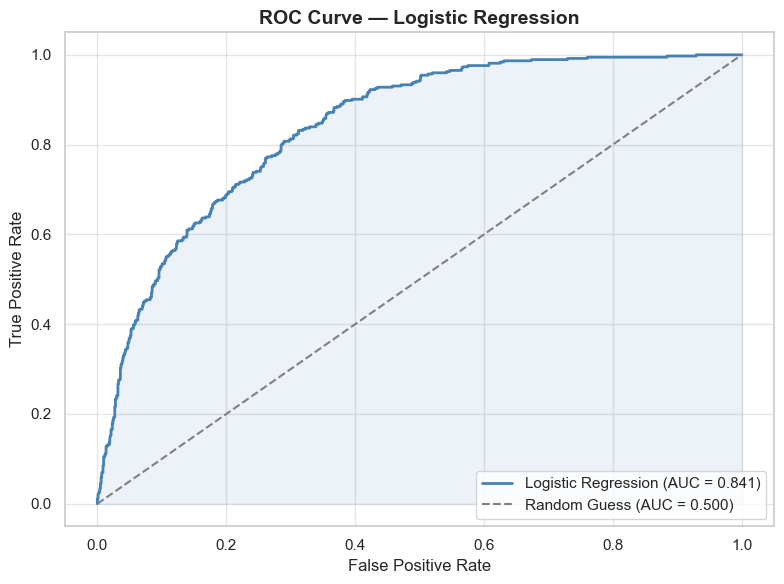


✅ AUC Score: 0.8408


In [19]:
# Cell 6 - ROC Curve
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))

# Model curve
ax.plot(
    fpr, tpr,
    color='steelblue',
    lw=2,
    label=f'Logistic Regression (AUC = {auc_score:.3f})'
)

# Random guess baseline
ax.plot(
    [0, 1], [0, 1],
    color='gray',
    linestyle='--',
    label='Random Guess (AUC = 0.500)'
)

# Shade area under curve
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(
    'ROC Curve — Logistic Regression',
    fontsize=14,
    fontweight='bold'
)
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig(ROC_CURVE_PATH,
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ AUC Score: {auc_score:.4f}")

# Cell 7 — Final Summary


In [20]:
# Cell 7 - Complete project summary
print(f"\n{'='*50}")
print(f"        FINAL MODEL SUMMARY REPORT")
print(f"{'='*50}")
print(f"  Model         : Logistic Regression")
print(f"  Best Params   : {lr_grid.best_params_}")
print(f"{'─'*50}")
print(f"  CV F1 Score   : {lr_grid.best_score_:.4f}")
print(f"  Test Accuracy : 0.80")
print(f"  Churned F1    : 0.59")
print(f"  Churned Recall: 0.55")
print(f"  AUC Score     : {auc_score:.4f}")
print(f"{'─'*50}")
print(f"  Confusion Matrix → {CONFUSION_MATRIX_PATH.name}")
print(f"  ROC Curve        → {ROC_CURVE_PATH.name}")
print(f"{'='*50}")
print(f"  ✅ Phase 5 Complete — Ready for Export")
print(f"{'='*50}")


        FINAL MODEL SUMMARY REPORT
  Model         : Logistic Regression
  Best Params   : {'classifier__C': 1, 'classifier__max_iter': 1000, 'classifier__solver': 'liblinear'}
──────────────────────────────────────────────────
  CV F1 Score   : 0.5971
  Test Accuracy : 0.80
  Churned F1    : 0.59
  Churned Recall: 0.55
  AUC Score     : 0.8408
──────────────────────────────────────────────────
  Confusion Matrix → confusion_matrix.png
  ROC Curve        → roc_curve.png
  ✅ Phase 5 Complete — Ready for Export


# Export All data into drive

In [21]:
# Cell 8 - Export trained pipeline
from src.predict import save_pipeline, load_pipeline

# Save best model pipeline
save_pipeline(best_model)

# Verify by reloading it
loaded_pipeline = load_pipeline()
print("\n✅ Pipeline exported and verified successfully")
print(f"   Saved at: {PIPELINE_PATH}")

✅ Pipeline saved → C:\Users\aadil\OneDrive\Desktop\Study\Intership DEV_HUB\Phase 2\Advance_Tasks\Task 2 customer-churn-pipeline\models\churn_pipeline.pkl
✅ Pipeline loaded from → C:\Users\aadil\OneDrive\Desktop\Study\Intership DEV_HUB\Phase 2\Advance_Tasks\Task 2 customer-churn-pipeline\models\churn_pipeline.pkl

✅ Pipeline exported and verified successfully
   Saved at: C:\Users\aadil\OneDrive\Desktop\Study\Intership DEV_HUB\Phase 2\Advance_Tasks\Task 2 customer-churn-pipeline\models\churn_pipeline.pkl


#  Prediction

In [22]:
# Cell 9 - Test prediction on sample customer
from src.predict import predict_churn

# Simulate a new customer (raw data - not preprocessed)
sample_customer = pd.DataFrame([{
    'customerID'      : 'TEST-001',
    'gender'          : 'Female',
    'SeniorCitizen'   : 0,
    'Partner'         : 'Yes',
    'Dependents'      : 'No',
    'tenure'          : 2,
    'PhoneService'    : 'Yes',
    'MultipleLines'   : 'No',
    'InternetService' : 'Fiber optic',
    'OnlineSecurity'  : 'No',
    'OnlineBackup'    : 'No',
    'DeviceProtection': 'No',
    'TechSupport'     : 'No',
    'StreamingTV'     : 'No',
    'StreamingMovies' : 'No',
    'Contract'        : 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod'   : 'Electronic check',
    'MonthlyCharges'  : 70.35,
    'TotalCharges'    : '140.70'
}])

# Drop customerID - not a feature
sample_customer_features = sample_customer.drop(
                                columns=['customerID'])

# Predict
result = predict_churn(sample_customer_features,
                        loaded_pipeline)

print("\n📊 Prediction Result:")
print(f"   Churn Prediction  : {result['Churn_Label'].values[0]}")
print(f"   Churn Probability : {result['Churn_Probability'].values[0]*100:.1f}%")


📊 Prediction Result:
   Churn Prediction  : Will Churn ⚠️
   Churn Probability : 70.8%
